# Optimized token demand across parameter regimes

This notebook studies how token demand responds to token price $c$, token efficiency $\eta$, and model capability $m$. Every point re-solves the user's choices:

- delegation horizon $s$ (human-hours of work between checkpoints),
- inference intensity $x$ (tokens per work-hour, per attempt), and
- retry cap $k$.

The user maximizes expected net surplus per scarce hour of human verification. All demand and spending figures use the abundant-work, attention-constrained regime with 100,000 human verification hours available per parameter regime and period. The level is a normalization; changing it scales demand without changing the curves. The calibrations isolate model mechanisms and should not be read as estimates.

## Setup

In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from modeling_token_demand import (
    AttentionConstrainedOptimizer,
    IndustryModel,
    OptimizationSettings,
    PolicyOptimizer,
    Scenario,
    illustrative_industries,
)

FIGURE_DIR = ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)
ATTENTION_HOURS_PER_INDUSTRY = 100_000.0
industries = tuple(
    replace(industry, human_attention_hours=ATTENTION_HOURS_PER_INDUSTRY)
    for industry in illustrative_industries(include_threshold=False)
)

## What distinguishes the parameter regimes

For a candidate user action $(s,x,k)$—delegation horizon, tokens per work-hour in each attempt, and retry cap—the parameters enter the model through the following chain. First, the capability and execution equations are

$$
q_i(s;m)=\exp\left[-\left(\frac{s}{\lambda_i m}\right)^{\nu_i}\right],
\qquad
r_i(s,x;m,\eta)=\exp\left[-\frac{s}{a_i m[\eta(x/x_{\mathrm{ref}})]^{\alpha_i}}\right].
$$

Here $q_i$ is the share of tasks inside the capability frontier, while $r_i$ is the success probability of one attempt conditional on the task being solvable. The normalization $x_{\mathrm{ref}}$ only keeps the numerical units convenient. With at most $k$ attempts,

$$
P_i=q_i[1-(1-r_i)^k],
\qquad
E_i=(1-q_i)k+q_i\frac{1-(1-r_i)^k}{r_i},
$$

where $P_i$ is eventual success and $E_i$ is expected attempts. Human verification time and expected surplus per work-hour are

$$
h_i(s)=v[h_{0,i}+h_{1,i}s^{\beta_i}],
\qquad
u_i(s,x,k)=b_iP_i-E_i\left(cx+w_i\frac{h_i(s)}{s}\right).
$$

There are two different user problems. With a fixed amount of work, the user chooses $(s,x,k)$ to maximize $u_i$. With abundant useful work and scarce human attention, one chunk creates expected surplus $s u_i$ and consumes $E_i h_i(s)$ expected verification hours. The relevant objective is therefore

$$
J_i(s,x,k)=\frac{s u_i(s,x,k)}{E_i h_i(s)}
=\frac{s}{h_i(s)}\left[\frac{b_iP_i}{E_i}-cx\right]-w_i.
$$

The attention-constrained user chooses $(s_i^\star,x_i^\star,k_i^\star)=\arg\max J_i$. In the broader work-limited model, optimized per-work surplus instead determines adoption:

$$
A_i=\frac{1}{1+\exp[-(u_i^\star-\mu_i)/\sigma_i]},
$$

$$
D_i^{\mathrm{work}}=W_iA_ix_i^\star E_i^\star,
\qquad
D_i^{\mathrm{attention}}=H_i\frac{s_i^\star x_i^\star}{h_i(s_i^\star)}.
$$

This notebook assumes useful work is abundant and human attention is the binding resource, so its main figures optimize $J_i$ and report $D_i=D_i^{\mathrm{attention}}$. The expected retry count cancels from demand because each retry consumes both another $sx$ tokens and another checkpoint $h_i(s)$. It does not cancel from $J_i$, because retrying changes expected value per verification hour. Adoption parameters and potential work volume therefore do not move these attention-constrained curves.

This makes the role of each parameter reasonably direct:

- $\lambda_i$ and $\nu_i$ shape the capability frontier $q_i$. A larger $\lambda_i$ supports longer tasks; $\nu_i$ controls how sharply feasibility falls near the frontier.
- $a_i$ and $\alpha_i$ shape conditional execution reliability $r_i$. A larger $a_i$ makes execution easier; $\alpha_i$ controls the diminishing return to additional inference.
- $h_{0,i}$, $h_{1,i}$, and $\beta_i$ determine human verification time. A $\beta_i$ near one means review grows almost proportionally with delegated scope.
- $b_i$ values successful work. The attention price $w_i$ determines whether operating is worthwhile but, because it enters $J_i$ as the constant $-w_i$, does not change the optimal policy in this strict binding-constraint case.
- $H_i$ is available human verification time and scales attention-limited demand proportionally.
- $\mu_i$, $\sigma_i$, and $W_i$ govern adoption and available work in the broader model, but they are inactive in the strictly attention-limited figures below.

The scenario variables are common comparative-statics inputs rather than regime characteristics: model capability $m$, token efficiency $\eta$, token price $c$, and the verification-time multiplier $v$.

In [2]:
characteristics = {
    "Sublinear verification": (
        "Broad capability frontier with verification that grows slowly with delegated scope."
    ),
    "Near-linear verification": (
        "Verification is expensive and grows nearly linearly with delegated scope."
    ),
    "Low-cost verification": (
        "Easy execution, a long capability horizon, and cheap, strongly sublinear verification."
    ),
    "Tight capability frontier": (
        "A short capability horizon and difficult execution, offset by high output value."
    ),
}

header = (
    "| Parameter regime | lambda | a | alpha | h1 | beta | b | mu | sigma | Defining feature |\n"
    "|---|---:|---:|---:|---:|---:|---:|---:|---:|---|\n"
)
rows = []
for industry in industries:
    rows.append(
        f"| {industry.name} | {industry.capability_horizon_hours:g} | "
        f"{industry.execution_scale:g} | {industry.inference_returns:g} | "
        f"{industry.verification_scale:g} | "
        f"{industry.verification_elasticity:g} | "
        f"{industry.value_per_work_hour:g} | {industry.adoption_midpoint:g} | "
        f"{industry.adoption_scale:g} | {characteristics[industry.name]} |"
    )
display(Markdown(header + "\n".join(rows)))

| Parameter regime | lambda | a | alpha | h1 | beta | b | mu | sigma | Defining feature |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---|
| Sublinear verification | 15 | 5 | 0.55 | 0.025 | 0.35 | 125 | 112 | 6 | Broad capability frontier with verification that grows slowly with delegated scope. |
| Near-linear verification | 12 | 4 | 0.5 | 0.13 | 0.95 | 125 | 100 | 7 | Verification is expensive and grows nearly linearly with delegated scope. |
| Low-cost verification | 40 | 8 | 0.45 | 0.012 | 0.25 | 100 | 30 | 8 | Easy execution, a long capability horizon, and cheap, strongly sublinear verification. |
| Tight capability frontier | 2 | 1.5 | 0.6 | 0.08 | 0.5 | 220 | 152 | 10 | A short capability horizon and difficult execution, offset by high output value. |

## Numerical solution

Both optimizers enumerate every integer retry cap and, conditional on each $k$, search for the best $(s,x)$ in log space using a grid plus bounded multi-start local optimization. The primary optimizer maximizes $J_i$, while the comparison optimizer maximizes $u_i$. The action ranges below are intentionally wide, and none of the plotted optima touches a continuous bound or the maximum retry cap.

In [3]:
settings = OptimizationSettings(
    min_delegation_hours=0.02,
    max_delegation_hours=80.0,
    min_tokens_per_work_hour=2_000.0,
    max_tokens_per_work_hour=20_000_000.0,
    max_attempts=12,
    grid_points_per_dimension=17,
    local_starts_per_attempt=4,
)
per_work_optimizer = PolicyOptimizer(settings)
attention_optimizer = AttentionConstrainedOptimizer(settings)
baseline = Scenario()

In [4]:
def solve_axis(policy_optimizer, scenario_field, values):
    """Reoptimize every industry at every value on one scenario axis."""
    results = {}
    for industry in industries:
        model = IndustryModel(industry)
        results[industry.name] = [
            policy_optimizer.solve(
                model, replace(baseline, **{scenario_field: float(value)})
            )
            for value in values
        ]
    return results


MARKERS = ("o", "s", "^", "D", "P")
PRICE_TICKS = (1, 2, 5, 10, 20, 40, 80)
TECHNOLOGY_TICKS = (0.35, 0.5, 1, 2, 3, 5)


def label_log_x_axis(ax, ticks):
    """Show informative numeric labels instead of sparse powers of ten."""
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{tick:g}" for tick in ticks])


def attention_limited_tokens(outcome):
    """Return demand under abundant work and a binding attention constraint."""
    if outcome.attention_limited_tokens is None:
        raise ValueError("human_attention_hours must be set for these plots")
    return outcome.attention_limited_tokens


def plot_demand(
    values, results, xlabel, filename, baseline_value, xticks, reverse_x=False
):
    """Plot every optimized demand point with an industry-specific marker."""
    fig, ax = plt.subplots(figsize=(10, 6.2), constrained_layout=True)
    for index, (industry_name, outcomes) in enumerate(results.items()):
        demand = np.array([attention_limited_tokens(outcome) / 1e9 for outcome in outcomes])
        ax.plot(
            values, demand, label=industry_name, marker=MARKERS[index],
            markersize=4.5, markeredgecolor="white", markeredgewidth=0.5,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    label_log_x_axis(ax, xticks)
    ax.axvline(baseline_value, color="0.35", linestyle="--", linewidth=1.2)
    if reverse_x:
        ax.invert_xaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Attention-limited token demand (billions per period)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    ax.legend(frameon=False, fontsize=9)
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    return fig


def plot_capability_objective_comparison(
    capabilities, attention_results, per_work_results, filename
):
    """Compare attention demand under the two policy objectives."""
    fig, axes = plt.subplots(
        2, 2, figsize=(11, 8), sharex=True, constrained_layout=True
    )
    for index, (industry_name, attention_outcomes) in enumerate(
        attention_results.items()
    ):
        ax = axes.flat[index]
        per_work_outcomes = per_work_results[industry_name]
        attention_demand = np.array([
            attention_limited_tokens(outcome) / 1e9
            for outcome in attention_outcomes
        ])
        per_work_demand = np.array([
            attention_limited_tokens(outcome) / 1e9
            for outcome in per_work_outcomes
        ])
        ax.plot(
            capabilities, attention_demand, color=f"C{index}", marker="o",
            markersize=3.8, markeredgecolor="white", markeredgewidth=0.4,
            label="Optimize per attention-hour",
        )
        ax.plot(
            capabilities, per_work_demand, color="0.35", linestyle="--",
            marker="x", markersize=4.0, label="Optimize per work-hour, then cap",
        )
        ax.set_xscale("log")
        ax.set_yscale("log")
        label_log_x_axis(ax, TECHNOLOGY_TICKS)
        ax.axvline(1.0, color="0.55", linestyle=":", linewidth=1.0)
        ax.set_title(industry_name)
        ax.grid(which="major", alpha=0.25)
        ax.grid(which="minor", alpha=0.08)

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="outside upper center", ncol=2, frameon=False
    )
    fig.supxlabel("Model capability, $m$")
    fig.supylabel("Attention-limited token demand (billions per period)")
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    return fig


def plot_token_spend(values, results, filename, xticks):
    """Plot c times D(c), with spending reported in millions of dollars."""
    fig, ax = plt.subplots(figsize=(10, 6.2), constrained_layout=True)
    for index, (industry_name, outcomes) in enumerate(results.items()):
        spend = np.array([
            attention_limited_tokens(outcome) * price_per_million / 1e12
            for outcome, price_per_million in zip(outcomes, values)
        ])
        ax.plot(
            values, spend, label=industry_name, marker=MARKERS[index],
            markersize=4.5, markeredgecolor="white", markeredgewidth=0.5,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    label_log_x_axis(ax, xticks)
    ax.axvline(10.0, color="0.35", linestyle="--", linewidth=1.2)
    ax.invert_xaxis()
    ax.set_xlabel("Token price, $ per million tokens (lower cost to the right)")
    ax.set_ylabel("Attention-limited token spend ($ millions per period)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    ax.legend(frameon=False, fontsize=9)
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    return fig


def plot_surplus_by_capability(capabilities, results, filename, xticks):
    """Plot optimized surplus as model capability changes."""
    fig, ax = plt.subplots(figsize=(10, 6.2), constrained_layout=True)
    for index, (industry_name, outcomes) in enumerate(results.items()):
        surplus = np.array([outcome.surplus_per_work_hour for outcome in outcomes])
        ax.plot(
            capabilities, surplus, label=industry_name, marker=MARKERS[index],
            markersize=4.5, markeredgecolor="white", markeredgewidth=0.5,
        )

    ax.set_xscale("log")
    label_log_x_axis(ax, xticks)
    ax.axvline(1.0, color="0.35", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Model capability, $m$")
    ax.set_ylabel("Optimized surplus, $u_i^\\star$ (dollars per work-hour)")
    ax.grid(which="major", alpha=0.25)
    ax.grid(which="minor", alpha=0.10)
    ax.legend(frameon=False, fontsize=9)
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    return fig


def print_retry_switches(values, results):
    """Describe the discrete choices behind visible demand kinks."""
    for industry_name, outcomes in results.items():
        retries = np.array([outcome.policy.max_attempts for outcome in outcomes])
        switches = np.flatnonzero(retries[1:] != retries[:-1]) + 1
        if len(switches):
            descriptions = [
                f"{values[j - 1]:.3g} to {values[j]:.3g}: k {retries[j - 1]} to {retries[j]}"
                for j in switches
            ]
            print(f"{industry_name}: " + "; ".join(descriptions))


def plot_attention_shadow_price(capabilities, results, filename):
    """Plot the level and exact capability elasticity of attention's shadow price."""
    fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2), constrained_layout=True)
    level_ax, elasticity_ax = axes
    industries_by_name = {industry.name: industry for industry in industries}

    for index, (industry_name, outcomes) in enumerate(results.items()):
        industry = industries_by_name[industry_name]
        shadow_prices = np.array([
            outcome.surplus_per_attention_hour + industry.human_cost_per_hour
            for outcome in outcomes
        ])
        elasticities = []
        for outcome in outcomes:
            s = outcome.policy.delegation_hours
            variable_review = (
                industry.verification_scale
                * s ** industry.verification_elasticity
            )
            theta = (
                industry.verification_elasticity * variable_review
                / (industry.verification_fixed_hours + variable_review)
            )
            elasticities.append(1.0 - theta)

        plot_options = dict(
            color=f"C{index}", marker=MARKERS[index], markersize=4.2,
            markeredgecolor="white", markeredgewidth=0.45,
        )
        level_ax.plot(
            capabilities, shadow_prices, label=industry_name, **plot_options
        )
        elasticity_ax.plot(capabilities, elasticities, **plot_options)

    for ax in axes:
        ax.set_xscale("log")
        label_log_x_axis(ax, TECHNOLOGY_TICKS)
        ax.axvline(1.0, color="0.45", linestyle="--", linewidth=1.1)
        ax.grid(which="major", alpha=0.25)
        ax.grid(which="minor", alpha=0.08)
        ax.set_xlabel("Model capability, $m$")

    level_ax.set_yscale("log")
    level_ax.set_ylabel("Shadow price, $ per additional attention hour")
    level_ax.legend(frameon=False, fontsize=8.5)
    elasticity_ax.set_ylim(0.0, 1.02)
    elasticity_ax.set_ylabel(
        r"Exact elasticity, $d\log \rho^\star / d\log m$"
    )
    fig.savefig(FIGURE_DIR / filename, dpi=180)
    return fig



### Baseline attention-constrained policies

In [5]:
baseline_rows = []
for industry in industries:
    outcome = attention_optimizer.solve(IndustryModel(industry), baseline)
    baseline_rows.append(
        f"| {industry.name} | {outcome.policy.delegation_hours:.3f} | "
        f"{outcome.policy.tokens_per_work_hour:,.0f} | {outcome.policy.max_attempts} | "
        f"{outcome.eventual_success:.1%} | "
        f"{outcome.surplus_per_attention_hour:,.0f} | "
        f"{attention_limited_tokens(outcome) / 1e9:.1f} |"
    )
baseline_header = (
    "| Parameter regime | s* (hours) | x* (tokens/hour) | k* | Success | Surplus/attention-hour | Attention demand (billions) |\n"
    "|---|---:|---:|---:|---:|---:|---:|\n"
)
display(Markdown(baseline_header + "\n".join(baseline_rows)))

| Parameter regime | s* (hours) | x* (tokens/hour) | k* | Success | Surplus/attention-hour | Attention demand (billions) |
|---|---:|---:|---:|---:|---:|---:|
| Sublinear verification | 5.676 | 1,132,359 | 1 | 55.1% | 3,940 | 7943.8 |
| Near-linear verification | 1.078 | 585,210 | 1 | 84.0% | 550 | 383.3 |
| Low-cost verification | 10.943 | 1,103,740 | 1 | 52.8% | 9,692 | 25794.5 |
| Tight capability frontier | 0.921 | 1,155,968 | 1 | 61.9% | 833 | 911.8 |

## Token price

The horizontal axis is reversed, so moving right means tokens become cheaper. The dashed line is the baseline price. Every optimized scenario is shown with an regime-specific marker, and the lines connect those solved points.

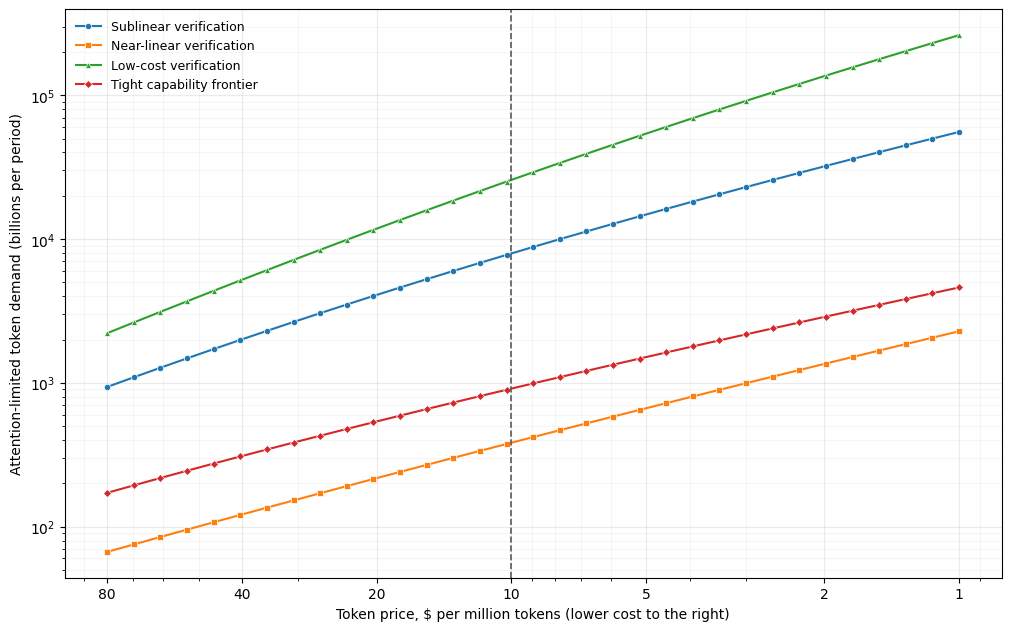

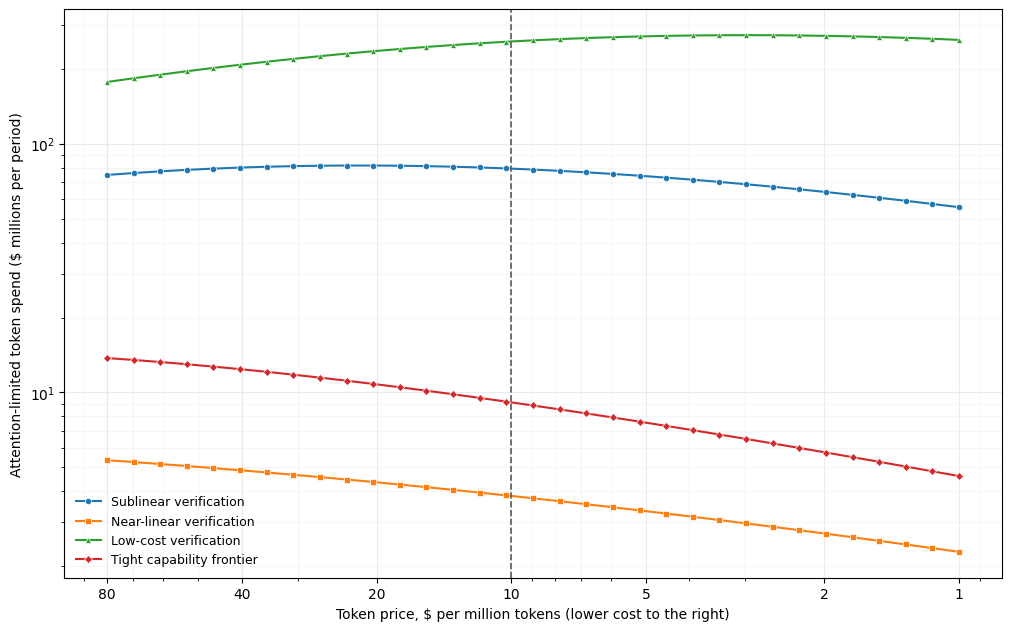

In [6]:
token_prices = np.geomspace(1.0, 80.0, 33)
price_results = solve_axis(
    attention_optimizer, "token_price_per_million", token_prices
)
print_retry_switches(token_prices, price_results)
price_figure = plot_demand(
    token_prices,
    price_results,
    xlabel="Token price, $ per million tokens (lower cost to the right)",
    filename="token-demand-vs-price.png",
    baseline_value=10.0,
    xticks=PRICE_TICKS,
    reverse_x=True,
)
spend_figure = plot_token_spend(
    token_prices, price_results, filename="token-spend-vs-price.png",
    xticks=PRICE_TICKS,
)

Cheaper tokens increase attention-limited demand because users choose greater inference intensity for each unit of work launched by a scarce human checkpoint. This is a quantity response to price. The efficiency experiment below asks the separate Jevons-style question: can making every token more effective increase total token use?

The second price figure reports token spend $cD(c)$. Moving right while a spending curve rises means token demand increased more than proportionally to the price decline, so the absolute price elasticity of demand exceeded one. Spending falls with cheaper tokens in most calibrations. The low-cost-verification regime has a limited intermediate rebound before turning down again: cheap, sublinear verification lets lower prices expand delegated scope unusually quickly, but the response is not sustained over the full range.

## Token efficiency

Higher $\eta$ means each token buys more effective inference while model capability $m$ is held fixed. Thus this experiment isolates efficiency from an outward shift in the capability frontier.

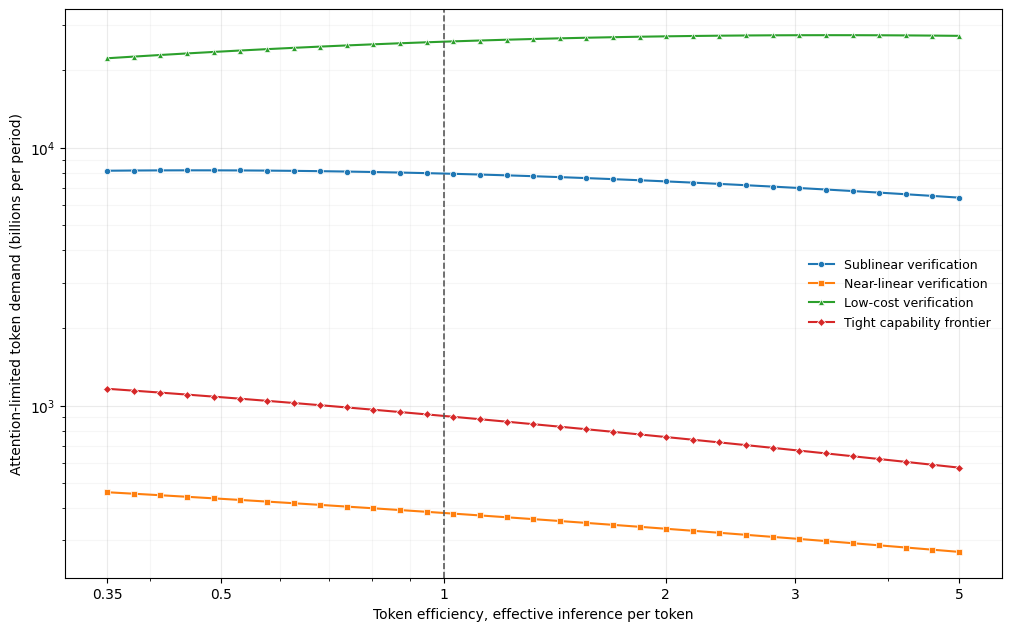

In [7]:
token_efficiencies = np.geomspace(0.35, 5.0, 33)
efficiency_results = solve_axis(
    attention_optimizer, "token_efficiency", token_efficiencies
)
print_retry_switches(token_efficiencies, efficiency_results)
efficiency_figure = plot_demand(
    token_efficiencies,
    efficiency_results,
    xlabel="Token efficiency, effective inference per token",
    filename="token-demand-vs-efficiency.png",
    baseline_value=1.0,
    xticks=TECHNOLOGY_TICKS,
)

In the attention-limited regime, efficiency affects demand through two opposing choices. It lowers the tokens needed for a given inference effort, but it may let each scarce human checkpoint launch a larger delegated chunk. Jevons-style growth occurs only if the increase in supervisory leverage $s_i^\star/h_i(s_i^\star)$ outweighs the decline in chosen token intensity $x_i^\star$.

The parameter regimes split. Near-linear verification and a tight capability frontier are efficiency-dominated, while sublinear verification is nearly flat at low $\eta$ before declining. Low-cost verification produces an intermediate rebound: demand rises from about 22.2 trillion tokens at $\eta=0.35$ to 27.3 trillion near $\eta=3$, then turns down slightly. Its low verification exponent ($\beta_i=0.25$) lets the optimal horizon grow from about 8.1 to 14.1 hours while inference intensity falls from about 1.24 million to 0.94 million tokens per work-hour. Supervisory leverage initially grows faster than token intensity falls. Once that expansion weakens, the direct efficiency effect dominates. Increasing model capability $m$ is a different experiment because it also moves the solvable-task frontier $q_i$.

## Model capability

Model capability directly expands the share of tasks inside the capability frontier:

$$
q_i(s;m)=\exp\left[-\left(\frac{s}{\lambda_i m}\right)^{\nu_i}\right],
\qquad
\frac{\partial q_i}{\partial m}
=\frac{q_i\nu_i}{m}\left(\frac{s}{\lambda_i m}\right)^{\nu_i}>0.
$$

Holding the task horizon $s$ fixed, $q_i$ therefore rises monotonically toward one as $m$ increases. The effect is largest when a parameter regime is near its capability frontier; once $q_i$ is already near one, this direct channel becomes small.

The plotted response is broader than this derivative. In the model, larger $m$ also raises conditional execution reliability $r_i$, and the attention-constrained user reoptimizes $s$, $x$, and $k$ to maximize $J_i$. Demand is then $H_i s_i^\star x_i^\star/h_i(s_i^\star)$. A line rises when capability expands work launched per checkpoint faster than chosen token intensity falls. The comparison figure also shows what happens under the old sequence: maximize per-work surplus $u_i$ first and only then apply the attention cap.

### Shadow price of scarce attention

It is useful to remove the separately specified attention charge and derive the value of the attention constraint itself. Define gross value per attention hour, after token spending but before any exogenous wage charge, as

$$
R_i(s,x,k;m)
=\frac{s}{h_i(s)}
\left[\frac{b_iP_i(s,x,k;m)}{E_i(s,x,k;m)}-cx\right].
$$

With abundant interchangeable work and a binding attention endowment $H_i$, the multiplier on $N_iE_ih_i(s)\leq H_i$ is

$$
\rho_i^\star(m)
=\max\left\{0,\max_{s,x,k}R_i(s,x,k;m)\right\}.
$$

This is the marginal optimized value of one additional human attention hour. The existing `AttentionConstrainedOptimizer` maximizes $J_i=R_i-w_i$. Since $w_i$ is constant, it already selects the same policy; its reported objective plus $w_i$ gives $\rho_i^\star$. If $w_i$ is instead a real wage paid in addition to the scarce endowment, $J_i^\star=\rho_i^\star-w_i$ is the scarcity rent after that wage.

The capability dependence can be characterized exactly. Because $k=1$ is optimal here, write

$$
A_i=\left(\frac{s}{\lambda_i m}\right)^{\nu_i},
\qquad
B_i=\frac{s}{a_i m[\eta(x/x_{\mathrm{ref}})]^{\alpha_i}},
\qquad
\theta_i(s)=\frac{s h_i'(s)}{h_i(s)}.
$$

The two interior first-order conditions are

$$
cx=\alpha_iB_i b_i e^{-A_i-B_i},
\qquad
\nu_iA_i+B_i=[1-\theta_i(s)](1-\alpha_iB_i).
$$

They reduce the two-dimensional continuous problem to one strictly increasing scalar equation. Set

$$
B_i(s,m)=
\frac{1-\theta_i(s)-\nu_iA_i(s,m)}
     {1+\alpha_i[1-\theta_i(s)]}.
$$

Then $s_i^\star$ is the unique positive root, before any imposed numerical action bounds, of

$$
\alpha_i\log\!\left(\frac{c x_{\mathrm{ref}}}{\alpha_i b_i\eta}\right)
+\log\!\left(\frac{s}{a_i m}\right)
+\alpha_iA_i-(\alpha_i+1)\log B_i+\alpha_iB_i=0,
$$

and

$$
x_i^\star=\frac{x_{\mathrm{ref}}}{\eta}
\left(\frac{s_i^\star}{a_i mB_i}\right)^{1/\alpha_i},
\qquad
\rho_i^\star=
\frac{s_i^\star}{h_i(s_i^\star)}
 b_i e^{-A_i-B_i}(1-\alpha_iB_i).
$$

For the calibrated form $h_i(s)=h_{0,i}+h_{1,i}s^{\beta_i}$ with $h_{0,i}>0$ and $0\leq\beta_i\leq1$, the envelope theorem gives the especially simple exact slope

$$
\boxed{
\frac{d\log\rho_i^\star}{d\log m}
=1-\theta_i(s_i^\star)
=1-\frac{\beta_i h_{1,i}(s_i^\star)^{\beta_i}}
{h_{0,i}+h_{1,i}(s_i^\star)^{\beta_i}}
}.
$$

Thus capability strictly raises the shadow price in these calibrations. Its elasticity lies between $1-\beta_i$ and $1$: capability is most valuable where verification grows slowly with task scope. There is generally no elementary closed form for $s_i^\star(m)$ because fixed and variable verification interact, but the boxed derivative and the scalar characterization are exact; the root below is solved to numerical tolerance rather than with a multidimensional local search.


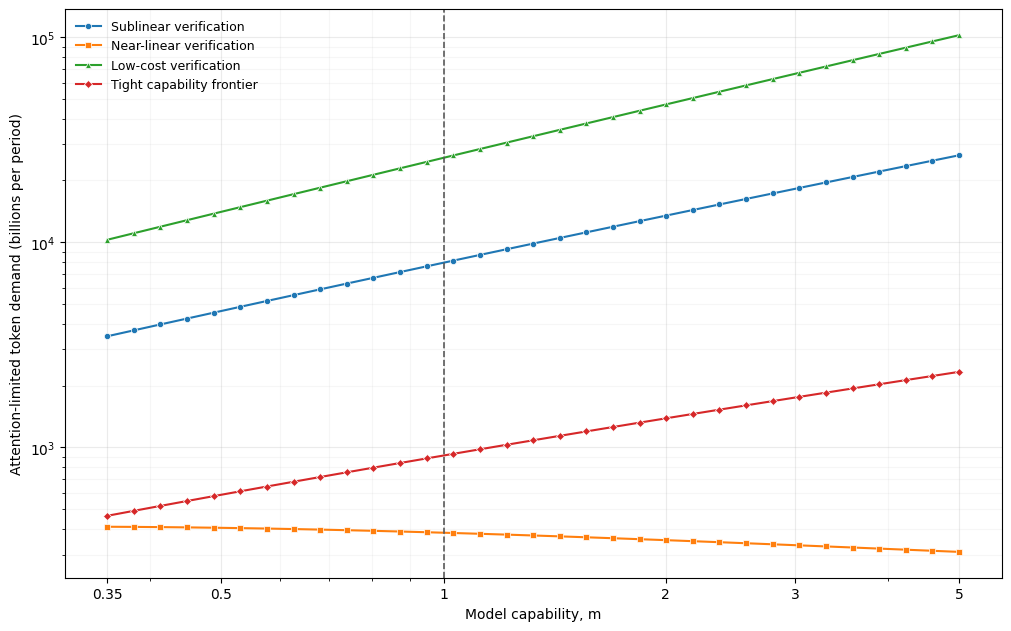

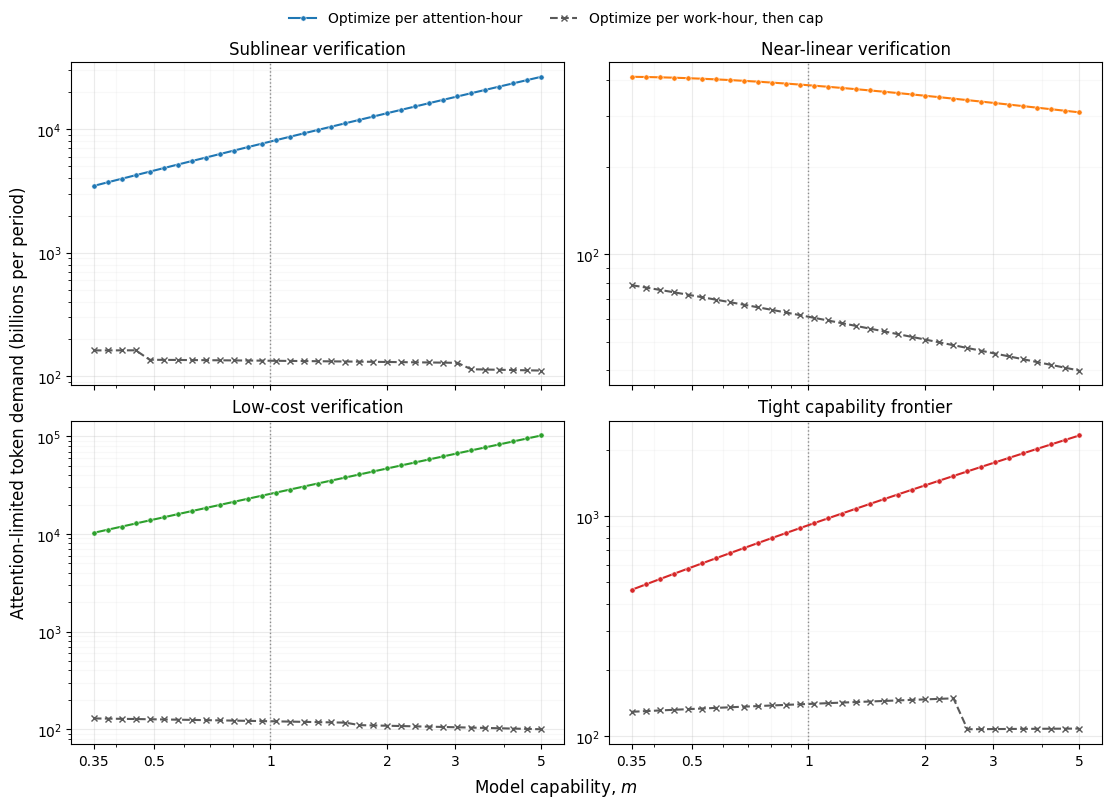

In [8]:
model_capabilities = np.geomspace(0.35, 5.0, 33)
attention_capability_results = solve_axis(
    attention_optimizer, "model_capability", model_capabilities
)
per_work_capability_results = solve_axis(
    per_work_optimizer, "model_capability", model_capabilities
)
print_retry_switches(model_capabilities, attention_capability_results)
capability_figure = plot_demand(
    model_capabilities,
    attention_capability_results,
    xlabel="Model capability, m",
    filename="token-demand-vs-capability.png",
    baseline_value=1.0,
    xticks=TECHNOLOGY_TICKS,
)
capability_comparison_figure = plot_capability_objective_comparison(
    model_capabilities,
    attention_capability_results,
    per_work_capability_results,
    filename="token-demand-vs-capability-objectives.png",
)

Largest relative difference between general and scalar solutions: 3.73e-13


| Parameter regime | $\rho^*(0.35)$ | $\rho^*(1)$ | $\rho^*(5)$ | Elasticity at $m=1$ |
|---|---:|---:|---:|---:|
| Sublinear verification | 1,714 | 4,040 | 14,147 | 0.801 |
| Near-linear verification | 506 | 650 | 825 | 0.194 |
| Low-cost verification | 3,831 | 9,767 | 39,687 | 0.883 |
| Tight capability frontier | 472 | 983 | 2,722 | 0.671 |

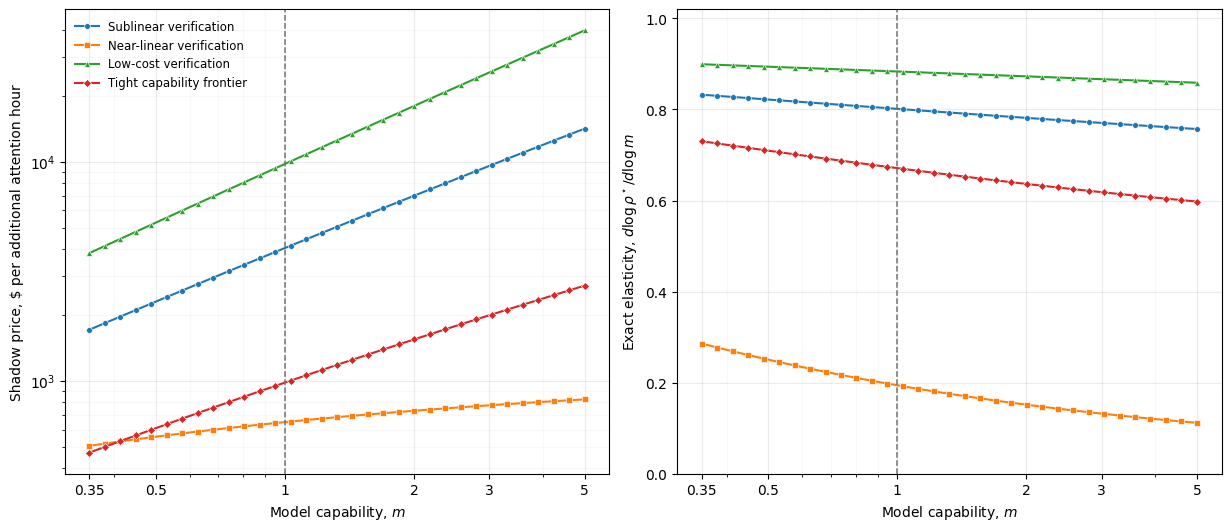

In [9]:
exact_attention_capability_results = {}
for industry in industries:
    model = IndustryModel(industry)
    exact_attention_capability_results[industry.name] = [
        attention_optimizer.solve_interior(
            model, replace(baseline, model_capability=float(capability))
        )
        for capability in model_capabilities
    ]

objective_differences = []
for industry in industries:
    name = industry.name
    for general, scalar in zip(
        attention_capability_results[name], exact_attention_capability_results[name]
    ):
        objective_differences.append(
            abs(general.surplus_per_attention_hour - scalar.surplus_per_attention_hour)
            / (abs(scalar.surplus_per_attention_hour) + industry.human_cost_per_hour)
        )
print(
    "Largest relative difference between general and scalar solutions: "
    f"{max(objective_differences):.2e}"
)

shadow_price_figure = plot_attention_shadow_price(
    model_capabilities,
    exact_attention_capability_results,
    filename="shadow-price-of-attention-vs-capability.png",
)

shadow_rows = []
for industry in industries:
    model = IndustryModel(industry)
    endpoint_outcomes = [
        attention_optimizer.solve_interior(
            model, replace(baseline, model_capability=capability)
        )
        for capability in (0.35, 1.0, 5.0)
    ]
    shadow_prices = [
        outcome.surplus_per_attention_hour + industry.human_cost_per_hour
        for outcome in endpoint_outcomes
    ]
    baseline_outcome = endpoint_outcomes[1]
    s = baseline_outcome.policy.delegation_hours
    variable_review = industry.verification_scale * (
        s ** industry.verification_elasticity
    )
    elasticity = 1.0 - (
        industry.verification_elasticity * variable_review
        / (industry.verification_fixed_hours + variable_review)
    )
    shadow_rows.append(
        f"| {industry.name} | {shadow_prices[0]:,.0f} | "
        f"{shadow_prices[1]:,.0f} | {shadow_prices[2]:,.0f} | "
        f"{elasticity:.3f} |"
    )
shadow_header = (
    "| Parameter regime | $\\rho^*(0.35)$ | $\\rho^*(1)$ | "
    "$\\rho^*(5)$ | Elasticity at $m=1$ |\n"
    "|---|---:|---:|---:|---:|\n"
)
display(Markdown(shadow_header + "\n".join(shadow_rows)))


The left panel reports the multiplier before subtracting the human-hour charge. It is positive and increasing throughout the plotted range in every parameter regime, so the maintained binding-attention assumption is internally consistent. The right panel reports the exact local elasticity rather than a finite-difference estimate.

The shadow value and token demand need not move together. Near-linear verification is the clearest case: capability raises the value produced by the marginal attention hour, but its verification technology makes the elasticity small and allows optimal token intensity to fall enough that token demand declines. The shadow value measures the gain from relaxing the human constraint; demand additionally depends on how the optimized policy divides that scarce hour between delegated scope and inference intensity.

The solid colored lines are the behaviorally consistent attention-constrained solution. The dashed gray lines reproduce the alternative sequence: choose the policy that maximizes surplus per unit of work, then calculate how much demand that policy would generate if attention happened to bind. That sequence treats human attention as an accounting cap without allowing it to change behavior.

The difference is large. A user maximizing $u_i$ prefers short, highly reliable chunks and economizes on tokens per unit of work. A user maximizing $J_i$ cares about how much net value each scarce verification hour supports. That user chooses much longer chunks and substantially greater inference intensity, accepting lower reliability on any one chunk when the increase in machine work launched per checkpoint is worthwhile.

Under the attention objective, token demand rises strongly with capability under sublinear verification, low-cost verification, and a tight capability frontier. For the sublinear-verification calibration, $(s^\star,x^\star)$ moves from $(5.68,1.13\text{ million})$ at $m=1$ to $(27.11,1.12\text{ million})$ at $m=5$, raising demand from 7.94 to 26.54 trillion tokens. Choosing $s$ roughly proportional to $m$ holds the reliability arguments approximately fixed, while $s/h_i(s)$ grows roughly as $m^{1-\beta_i}$ when variable verification dominates. Near-linear verification is the exception. Its $\beta_i=0.95$ makes review grow almost one-for-one with delegated scope, so a longer horizon adds little supervisory leverage and demand falls as execution becomes more efficient. Adoption does not enter this polar case; capability operates through the chosen policy and work supervised per human hour.

### Per-work surplus as capability improves

The next figure deliberately retains the per-work optimizer, so $u_i^\star=\max u_i$ keeps its usual meaning and can later feed the adoption equation. It is a separate economic object from the attention objective $J_i^\star$.

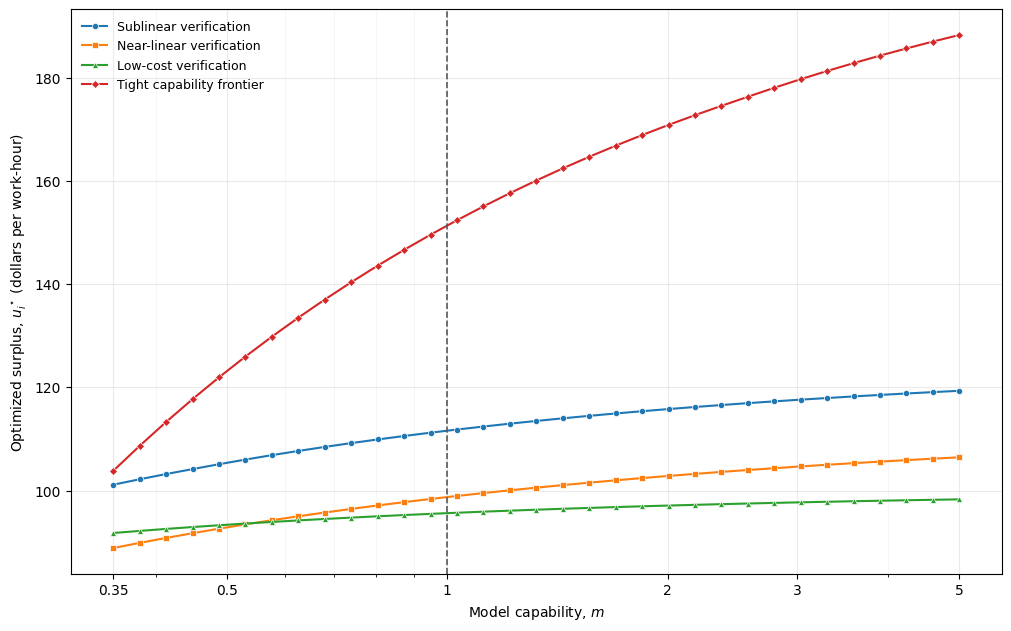

In [10]:
surplus_capability_figure = plot_surplus_by_capability(
    model_capabilities,
    per_work_capability_results,
    filename="optimized-surplus-vs-model-capability.png",
    xticks=TECHNOLOGY_TICKS,
)

The adoption-threshold calibration is intentionally excluded from the attention-demand figures because it differs from the sublinear-verification calibration only through $\mu_i$ and $\sigma_i$, which do not enter the binding-attention policy problem. It is retained for work-limited comparisons. The dashed vertical line marks baseline capability $m=1$.

## Retry choice with abundant interchangeable work

The attention-constrained solution chooses $k=1$ throughout these sweeps. This is not an optimizer accident. At a fixed $(s,x)$, $P_k/E_k\leq qr=P_1/E_1$ because $1-(1-r)^k\leq kr$. A failed attempt makes the same task more likely to lie in the unsolvable tail, while a fresh task is another draw from the prior. When useful tasks are abundant and interchangeable, restarting on a new task therefore weakly dominates retrying the old one per unit of scarce verification time.

Retries can reappear when the amount of useful work is fixed, abandoning a partially completed task is costly, task values differ, attempts learn from earlier failures, or setup/context is reusable. Those are important extensions, but they are not present in this polar case. The table below verifies the numerical choice across all three sweeps.

In [11]:
retry_rows = []
for industry in industries:
    name = industry.name
    price_ks = sorted({item.policy.max_attempts for item in price_results[name]})
    efficiency_ks = sorted({item.policy.max_attempts for item in efficiency_results[name]})
    capability_ks = sorted({item.policy.max_attempts for item in attention_capability_results[name]})
    retry_rows.append(
        f"| {name} | {price_ks} | {efficiency_ks} | {capability_ks} |"
    )
retry_header = (
    "| Parameter regime | k across price sweep | k across efficiency sweep | k across capability sweep |\n"
    "|---|---:|---:|---:|\n"
)
display(Markdown(retry_header + "\n".join(retry_rows)))

| Parameter regime | k across price sweep | k across efficiency sweep | k across capability sweep |
|---|---:|---:|---:|
| Sublinear verification | [1] | [1] | [1] |
| Near-linear verification | [1] | [1] | [1] |
| Low-cost verification | [1] | [1] | [1] |
| Tight capability frontier | [1] | [1] | [1] |

### Optimizer audit

The optimizer searches a log grid and refines multiple starting points for every retry cap. The price range exposed an old upper bound on inference intensity, so that bound was widened tenfold before generating these figures. Across the final price, efficiency, and capability sweeps, none of the 396 attention-constrained policies touches a continuous bound. All select $k=1$, consistent with the analytical dominance result above. Twenty-four representative boundary scenarios were also compared with SciPy's independent differential-evolution optimizer; the largest relative objective difference was $2.3\times10^{-11}$. The new scalar first-order solver independently matches every general capability-sweep objective to within $3.8\times10^{-13}$ in relative terms. These checks support both the plotted shapes and the analytical reduction.

All demand and spending plots assume abundant useful work and 100,000 available human verification hours per parameter regime. The primary curves reoptimize behavior under the binding attention constraint. The capability comparison retains the earlier per-work-hour policy solely to show how changing the behavioral assumption changes the result.